# 01 - Probability Basics for Variational Inference

Before we can understand variational inference, we need to be comfortable with:
1. Probability distributions - what they are, how to work with them
2. Bayes' theorem - updating beliefs with evidence
3. The inference problem - why we need approximations

Let's build this intuition step by step.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Make plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)  # For reproducibility

## Part 1: What is a Probability Distribution?

A probability distribution tells us how likely different outcomes are.

### Example: Rolling a fair die
Each face (1-6) has probability 1/6. This is a **discrete** distribution.

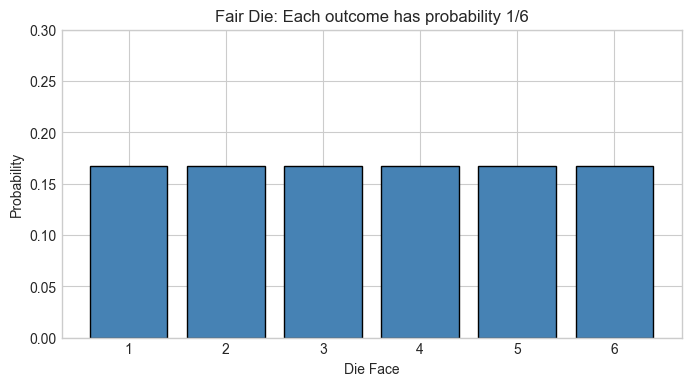

Sum of all probabilities: 1.0
(Probabilities must always sum to 1!)


In [25]:
# Rolling a fair die - discrete uniform distribution
faces = [1, 2, 3, 4, 5, 6]
probabilities = [1/len(faces)] * len(faces)  # Each face has equal probability

plt.figure(figsize=(8, 4))
plt.bar(faces, probabilities, color='steelblue', edgecolor='black')
plt.xlabel('Die Face')
plt.ylabel('Probability')
plt.title('Fair Die: Each outcome has probability 1/6')
plt.ylim(0, 0.3)
plt.show()

print(f"Sum of all probabilities: {sum(probabilities)}")
print("(Probabilities must always sum to 1!)")

### Sampling from a distribution

"Sampling" means generating random values according to the distribution.
If we sample many times, we should see the distribution emerge.

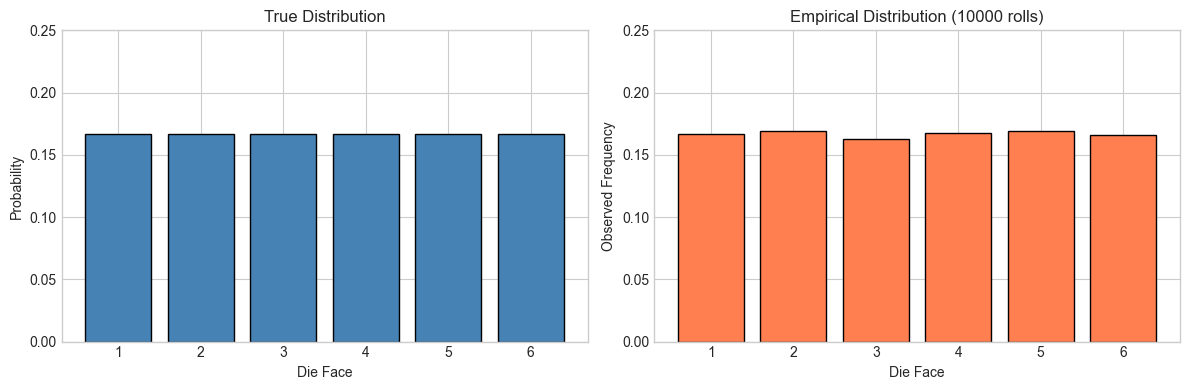

Notice: The more we sample, the closer we get to the true distribution!


In [26]:
# Let's "roll the die" many times and see what happens
n_rolls = 10000
rolls = np.random.choice(faces, size=n_rolls)  # Sample from our distribution

# Count how often each face appeared
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: True distribution
axes[0].bar(faces, probabilities, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Die Face')
axes[0].set_ylabel('Probability')
axes[0].set_title('True Distribution')
axes[0].set_ylim(0, 0.25)

# Right: Empirical distribution from samples
counts = [np.sum(rolls == f) / n_rolls for f in faces]
axes[1].bar(faces, counts, color='coral', edgecolor='black')
axes[1].set_xlabel('Die Face')
axes[1].set_ylabel('Observed Frequency')
axes[1].set_title(f'Empirical Distribution ({n_rolls} rolls)')
axes[1].set_ylim(0, 0.25)

plt.tight_layout()
plt.show()

print("Notice: The more we sample, the closer we get to the true distribution!")

## Part 2: Continuous Distributions - The Gaussian (Normal)

The most important continuous distribution is the **Gaussian** (or Normal) distribution.

It's defined by two parameters:
- **μ (mu)**: the mean - where the center is
- **σ (sigma)**: the standard deviation - how spread out it is

Written as: X ~ N(μ, σ²)

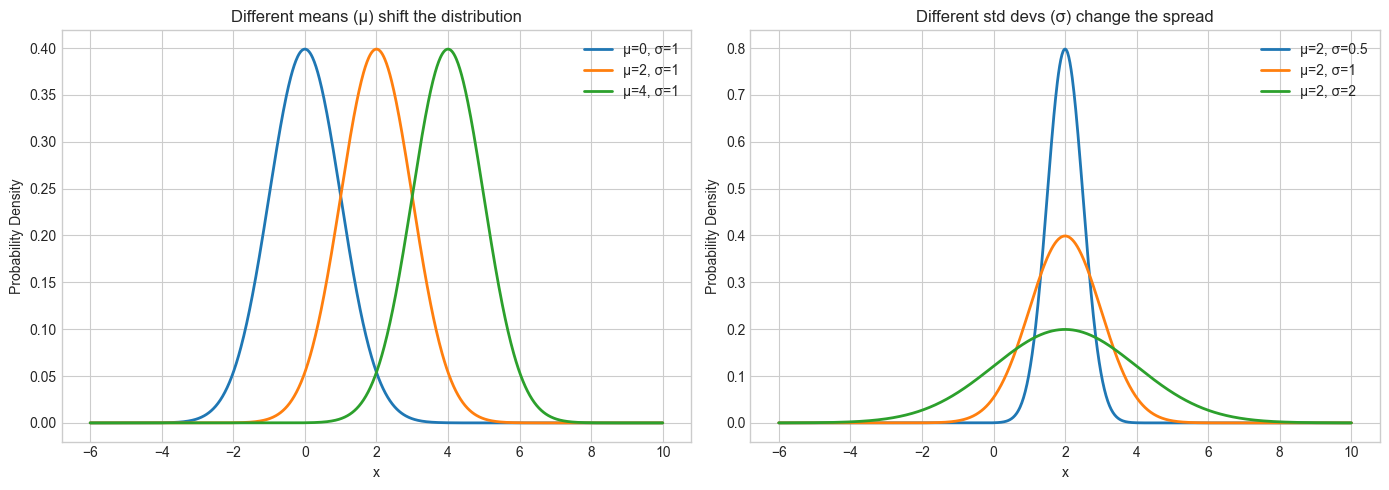

In [27]:
# Let's visualize Gaussians with different parameters
x = np.linspace(-6, 10, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Same sigma, different mu
for mu in [0, 2, 4]:
    y = stats.norm.pdf(x, loc=mu, scale=1)  # scale = sigma
    axes[0].plot(x, y, label=f'μ={mu}, σ=1', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Different means (μ) shift the distribution')
axes[0].legend()

# Right: Same mu, different sigma
for sigma in [0.5, 1, 2]:
    y = stats.norm.pdf(x, loc=2, scale=sigma)
    axes[1].plot(x, y, label=f'μ=2, σ={sigma}', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Probability Density')
axes[1].set_title('Different std devs (σ) change the spread')
axes[1].legend()

plt.tight_layout()
plt.show()

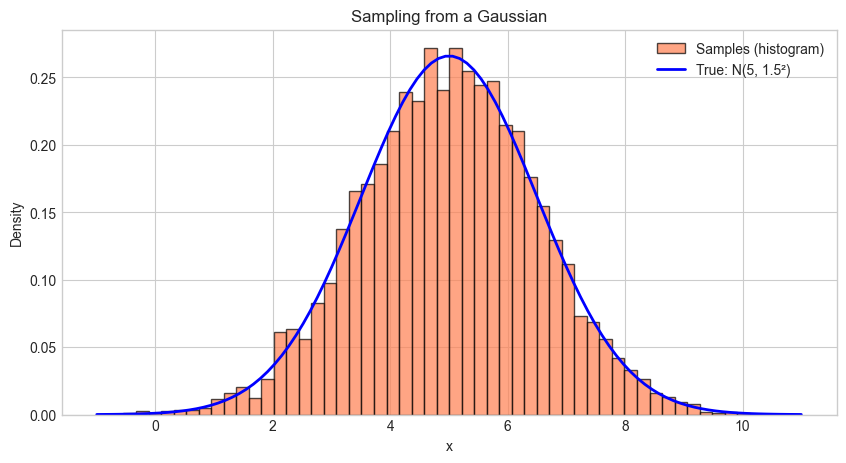

Sample mean: 4.996 (true: 5)
Sample std:  1.510 (true: 1.5)


In [28]:
# Sampling from a Gaussian
mu, sigma = 5, 1.5
samples = np.random.normal(mu, sigma, size=5000)

plt.figure(figsize=(10, 5))

# Histogram of samples
plt.hist(samples, bins=50, density=True, alpha=0.7, color='coral', 
         edgecolor='black', label='Samples (histogram)')

# True distribution
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'b-', linewidth=2, 
         label=f'True: N({mu}, {sigma}²)')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Sampling from a Gaussian')
plt.legend()
plt.show()

print(f"Sample mean: {np.mean(samples):.3f} (true: {mu})")
print(f"Sample std:  {np.std(samples):.3f} (true: {sigma})")

## Part 3: Bayes' Theorem - Updating Beliefs

This is the heart of probabilistic inference.

### The Setup
- **Prior**: What we believe before seeing data
- **Likelihood**: How probable is the data given our belief?
- **Posterior**: What we should believe after seeing data

### Bayes' Theorem
$$P(\theta | \text{data}) = \frac{P(\text{data} | \theta) \cdot P(\theta)}{P(\text{data})}$$

Or in words:
$$\text{Posterior} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}$$

### Example: Is this coin fair?

Imagine you have a coin. You don't know if it's fair or biased.

Let θ = probability the coin lands heads.
- If fair: θ = 0.5
- If biased towards heads: θ > 0.5
- If biased towards tails: θ < 0.5

**Our goal**: Given some coin flips, what do we believe about θ?

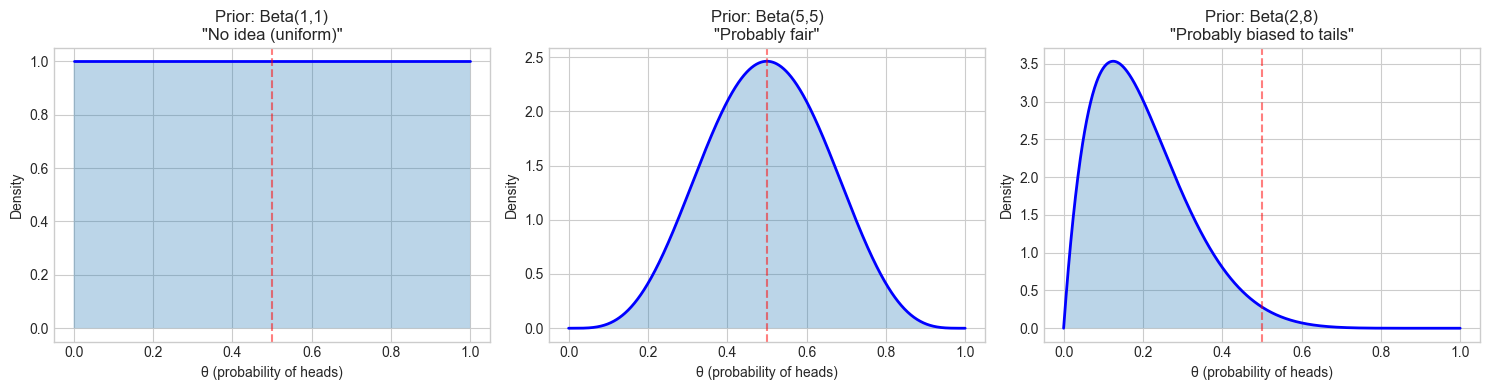

In [29]:
# The Beta distribution is perfect for modeling probabilities (values between 0 and 1)
# Beta(α, β) where:
#   - Higher α = more belief in heads
#   - Higher β = more belief in tails
#   - α = β = 1 means "I have no idea" (uniform prior)

theta = np.linspace(0, 1, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Different priors
priors = [
    (1, 1, 'No idea (uniform)'),
    (5, 5, 'Probably fair'),
    (2, 8, 'Probably biased to tails')
]

for ax, (a, b, title) in zip(axes, priors):
    y = stats.beta.pdf(theta, a, b)
    ax.plot(theta, y, 'b-', linewidth=2)
    ax.fill_between(theta, y, alpha=0.3)
    ax.set_xlabel('θ (probability of heads)')
    ax.set_ylabel('Density')
    ax.set_title(f'Prior: Beta({a},{b})\n"{title}"')
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Updating our belief with data

Magic property of Beta-Binomial: If we start with Beta(α, β) prior and observe:
- h heads
- t tails

Then our posterior is simply: **Beta(α + h, β + t)**

Let's watch our belief update as we see more coin flips!

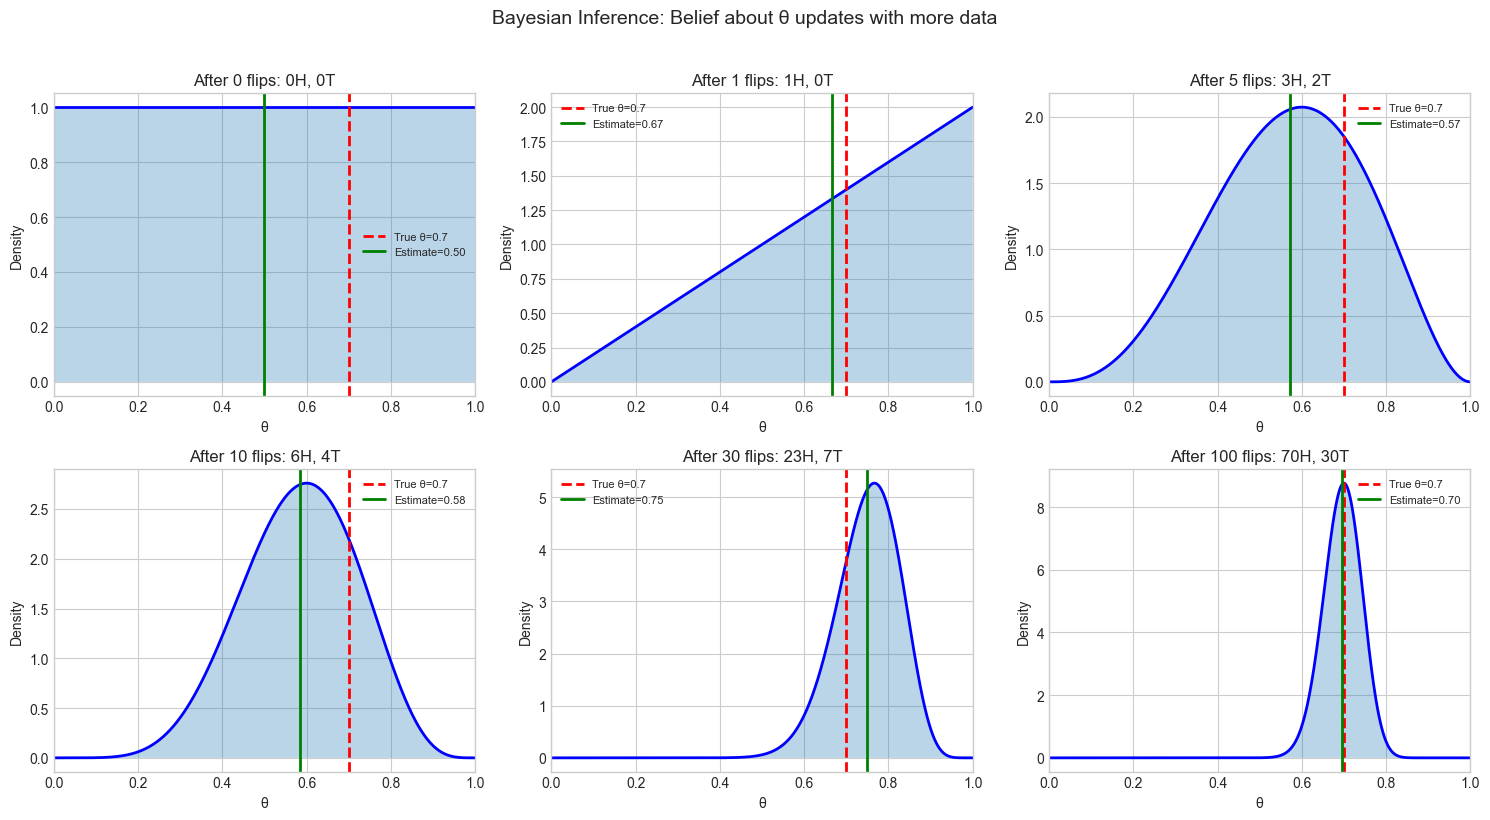

In [30]:
# Simulate a BIASED coin (true θ = 0.7, biased towards heads)
true_theta = 0.7
np.random.seed(42)

# Generate some coin flips
n_flips = 100
flips = np.random.binomial(1, true_theta, n_flips)  # 1=heads, 0=tails

# Start with uniform prior: Beta(1, 1) - "I have no idea"
alpha_prior, beta_prior = 1, 1

# Watch our belief evolve
theta = np.linspace(0, 1, 1000)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

checkpoints = [0, 1, 5, 10, 30, 100]

for ax, n in zip(axes, checkpoints):
    # Count heads and tails so far
    heads = np.sum(flips[:n])
    tails = n - heads
    
    # Posterior parameters
    alpha_post = alpha_prior + heads
    beta_post = beta_prior + tails
    
    # Plot posterior
    y = stats.beta.pdf(theta, alpha_post, beta_post)
    ax.plot(theta, y, 'b-', linewidth=2)
    ax.fill_between(theta, y, alpha=0.3)
    
    # Mark true value
    ax.axvline(x=true_theta, color='red', linestyle='--', linewidth=2, label=f'True θ={true_theta}')
    
    # Mark posterior mean
    post_mean = alpha_post / (alpha_post + beta_post)
    ax.axvline(x=post_mean, color='green', linestyle='-', linewidth=2, label=f'Estimate={post_mean:.2f}')
    
    ax.set_xlabel('θ')
    ax.set_ylabel('Density')
    ax.set_title(f'After {n} flips: {heads}H, {tails}T')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.suptitle('Bayesian Inference: Belief about θ updates with more data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Key observations:

1. **Prior (0 flips)**: Wide, uncertain - we have no idea
2. **After 1 flip**: Still very uncertain, but slightly shifted
3. **After 100 flips**: Very confident! Distribution is tight around the true value

This is Bayesian inference in action:
- Start with uncertainty (prior)
- Observe data
- End with reduced uncertainty (posterior)

**The posterior distribution captures both our estimate AND our uncertainty!**

## Part 4: The Inference Problem - Why We Need Approximations

The coin example worked perfectly because:
1. Beta prior + Binomial likelihood = Beta posterior (conjugate pair)
2. We could compute the posterior exactly

### But in real problems...

Remember Bayes' theorem:
$$P(\theta | \text{data}) = \frac{P(\text{data} | \theta) \cdot P(\theta)}{P(\text{data})}$$

The denominator $P(\text{data})$ is called the **evidence** or **marginal likelihood**:
$$P(\text{data}) = \int P(\text{data} | \theta) \cdot P(\theta) \, d\theta$$

**This integral is often impossible to compute!**

When:
- θ is high-dimensional (many parameters)
- The likelihood is complex (neural networks, etc.)
- Prior and likelihood don't have a nice conjugate relationship

/var/folders/86/_9q8k9vj4232chyb07p3cwym0000gn/T/ipykernel_18554/802134928.py:40: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/86/_9q8k9vj4232chyb07p3cwym0000gn/T/ipykernel_18554/802134928.py:40: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/kaicho/Develop/variational-inference/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kaicho/Develop/variational-inference/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


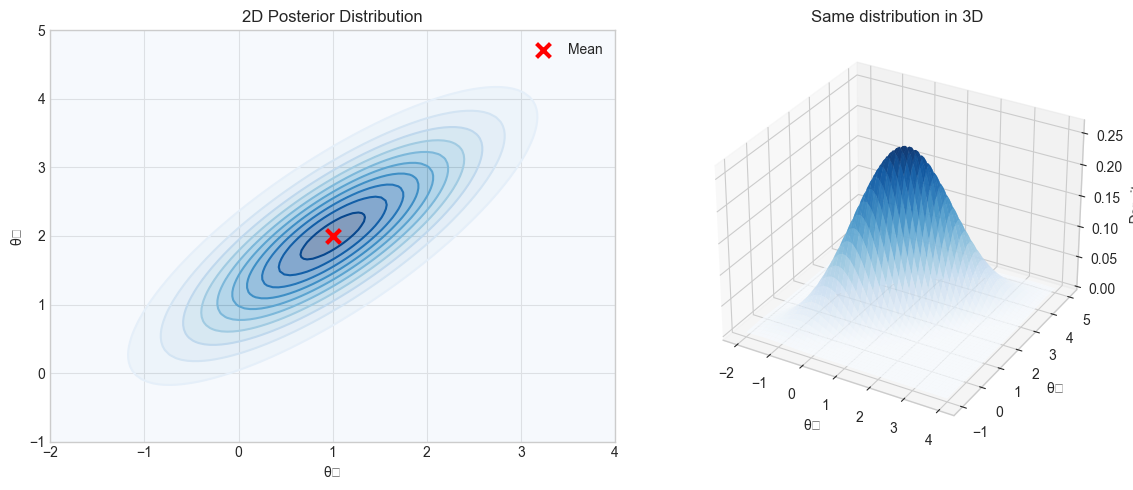

With 2 parameters, we need to integrate over a 2D space.
With 1000 parameters, we need to integrate over 1000 dimensions!
Neural networks can have MILLIONS of parameters...


In [31]:
# Simple example: What if θ has TWO dimensions?
# Even with just 2D, visualizing and computing gets harder

# Create a 2D Gaussian posterior (pretend this is our true posterior)
mean = [1, 2]
cov = [[1, 0.8], [0.8, 1]]  # Correlated!

# Create grid for visualization
x = np.linspace(-2, 4, 100)
y = np.linspace(-1, 5, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# Compute density
rv = stats.multivariate_normal(mean, cov)
Z = rv.pdf(pos)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contour plot
axes[0].contour(X, Y, Z, levels=10, cmap='Blues')
axes[0].contourf(X, Y, Z, levels=10, cmap='Blues', alpha=0.5)
axes[0].scatter(*mean, color='red', s=100, marker='x', linewidths=3, label='Mean')
axes[0].set_xlabel('θ₁')
axes[0].set_ylabel('θ₂')
axes[0].set_title('2D Posterior Distribution')
axes[0].legend()

# 3D surface
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='Blues', alpha=0.8)
ax3d.set_xlabel('θ₁')
ax3d.set_ylabel('θ₂')
ax3d.set_zlabel('Density')
ax3d.set_title('Same distribution in 3D')

# Remove the original 2nd subplot since we replaced it
axes[1].remove()

plt.tight_layout()
plt.show()

print("With 2 parameters, we need to integrate over a 2D space.")
print("With 1000 parameters, we need to integrate over 1000 dimensions!")
print("Neural networks can have MILLIONS of parameters...")

## The Two Main Solutions

When exact inference is impossible, we have two main approaches:

### 1. MCMC (Markov Chain Monte Carlo)
- Generate samples from the posterior
- "Random walk" that explores high-probability regions
- Accurate but can be slow

### 2. Variational Inference (VI) ← This is what we'll learn!
- Approximate the posterior with a simpler distribution
- Turn inference into optimization
- Faster but approximate

**In the next notebook, we'll dive into the core idea of VI:**
- How do we measure "closeness" between distributions? (KL divergence)
- How do we find the best approximation? (ELBO)

## Summary

What we learned:

1. **Probability distributions** describe uncertainty about outcomes
2. **Sampling** generates random values according to a distribution
3. **Bayes' theorem** lets us update beliefs with evidence
4. **The posterior** captures both our estimate AND uncertainty
5. **Computing the posterior exactly is often impossible** in real problems
6. **Variational inference** will let us approximate when exact is impossible

### Exercises (optional)

1. Change `true_theta` to 0.3 and re-run the coin flip example. How does the posterior evolve?
2. What happens if you start with a strong prior Beta(10, 10) instead of Beta(1, 1)?
3. How many flips do you need to be "confident" about θ? (Hint: look at the width of the posterior)

In [32]:
# Your experiments here!
